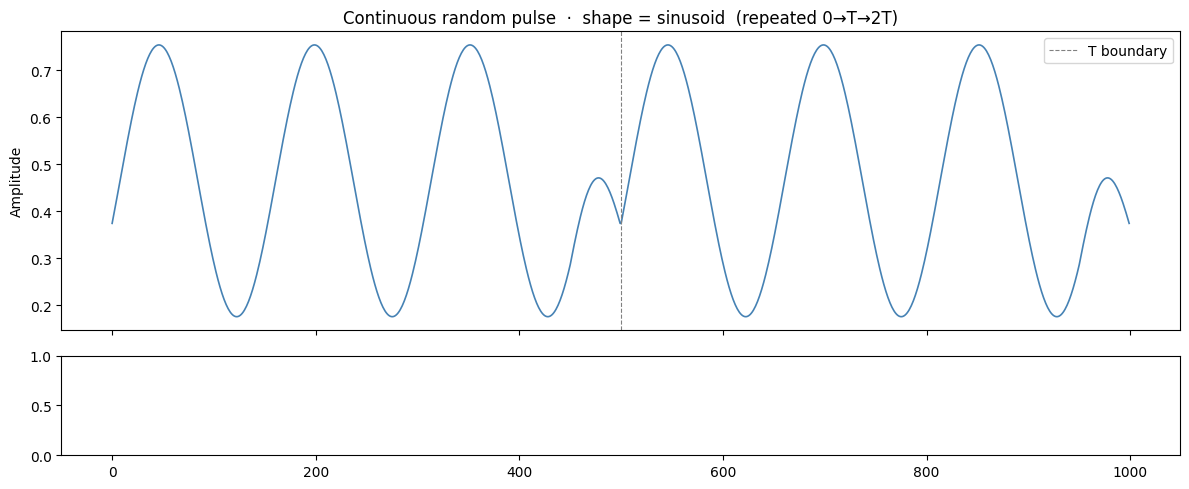

Chosen shape function : sinusoid
Pulse length (T)      : 500
Total signal length   : 1000
Jump at T boundary    : 0.000000


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from NeuralFieldManifold.generators.tvar import (
    sinusoid, fourier, quasiperiodic, polynomial_drift,
    logistic_transition, multi_sigmoid, gaussian_bumps, smooth_random,
)

# --- Configuration ---
T   = 500        # samples per pulse period
p   = 1          # single channel (1 lag → 1-D signal)
seed = 42
rng  = np.random.default_rng(seed)

# Pool of shape generators
shape_funcs = {
    "sinusoid":            sinusoid,
    "fourier":             fourier,
    "quasiperiodic":       quasiperiodic,
    "polynomial_drift":    polynomial_drift,
    "logistic_transition": logistic_transition,
    "multi_sigmoid":       multi_sigmoid,
    "gaussian_bumps":      gaussian_bumps,
    "smooth_random":       smooth_random,
}

# --- Pick a random shape and generate the raw pulse ---
name = rng.choice(list(shape_funcs.keys()))
gen  = shape_funcs[name]
raw_pulse = gen(T, p, rng).ravel()          # shape (T,)

# --- Make it continuous (no jump when tiled) ---
# Crossfade the tail back toward pulse[0] over the last 10% of the period
fade_len = T // 10
alpha = np.linspace(0, 1, fade_len)
pulse = raw_pulse.copy()
pulse[-fade_len:] = (1 - alpha) * raw_pulse[-fade_len:] + alpha * raw_pulse[0]

# Repeat: [0, T) then [T, 2T)  — now continuous at the boundary
signal = np.tile(pulse, 2)
t_axis = np.arange(2 * T)

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(t_axis, signal, lw=1.2, color="steelblue")
axes[0].axvline(T, ls="--", color="gray", lw=0.8, label="T boundary")
axes[0].set_ylabel("Amplitude")
axes[0].set_title(f"Continuous random pulse  ·  shape = {name}  (repeated 0→T→2T)")
axes[0].legend(loc="upper right")


plt.tight_layout()
plt.show()

# Verify continuity at the boundary
print(f"Chosen shape function : {name}")
print(f"Pulse length (T)      : {T}")
print(f"Total signal length   : {len(signal)}")
print(f"Jump at T boundary    : {abs(signal[T] - signal[T-1]):.6f}")

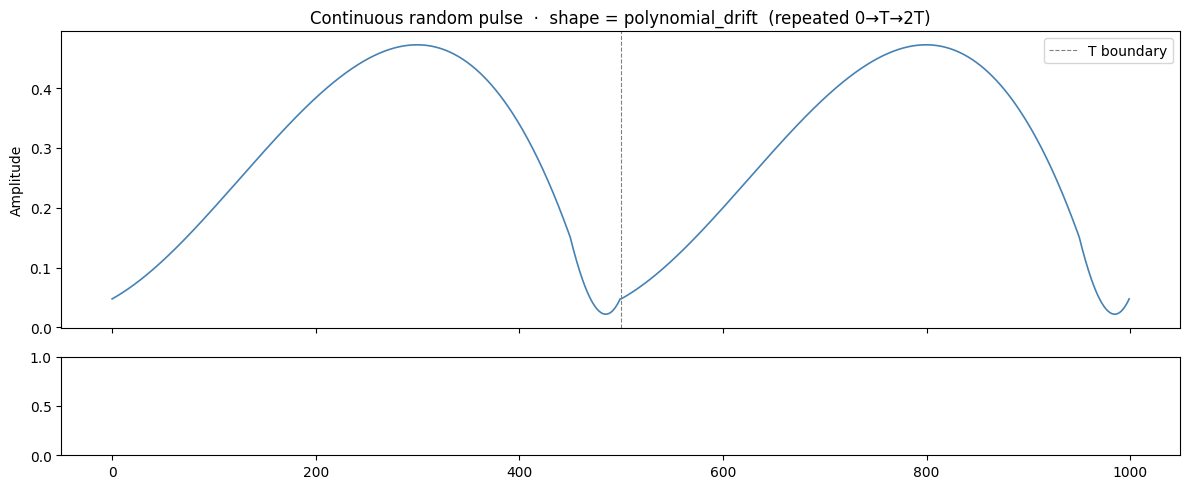

Chosen shape function : polynomial_drift
Pulse length (T)      : 500
Total signal length   : 1000
Jump at T boundary    : 0.000000


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from NeuralFieldManifold.generators.tvar import (
    polynomial_drift,
    logistic_transition,
    multi_sigmoid,
    gaussian_bumps,
    smooth_random,
)

# --- Configuration ---
T   = 500        # samples per pulse period
p   = 1          # single channel (1 lag → 1-D signal)
seed = 42
rng  = np.random.default_rng(seed)

# Pool of NON-OSCILLATORY shape generators only
shape_funcs = {
    "polynomial_drift":    polynomial_drift,
    "logistic_transition": logistic_transition,
    "multi_sigmoid":       multi_sigmoid,
    "gaussian_bumps":      gaussian_bumps,
    "smooth_random":       smooth_random,
}

# --- Pick a random shape and generate the raw pulse ---
name = rng.choice(list(shape_funcs.keys()))
gen  = shape_funcs[name]
raw_pulse = gen(T, p, rng).ravel()          # shape (T,)

# --- Make it continuous (no jump when tiled) ---
fade_len = T // 10
alpha = np.linspace(0, 1, fade_len)
pulse = raw_pulse.copy()
pulse[-fade_len:] = (1 - alpha) * raw_pulse[-fade_len:] + alpha * raw_pulse[0]

# Repeat: [0, T) then [T, 2T)
signal = np.tile(pulse, 2)
t_axis = np.arange(2 * T)

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(t_axis, signal, lw=1.2, color="steelblue")
axes[0].axvline(T, ls="--", color="gray", lw=0.8, label="T boundary")
axes[0].set_ylabel("Amplitude")
axes[0].set_title(f"Continuous random pulse  ·  shape = {name}  (repeated 0→T→2T)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"Chosen shape function : {name}")
print(f"Pulse length (T)      : {T}")
print(f"Total signal length   : {len(signal)}")
print(f"Jump at T boundary    : {abs(signal[T] - signal[T-1]):.6f}")

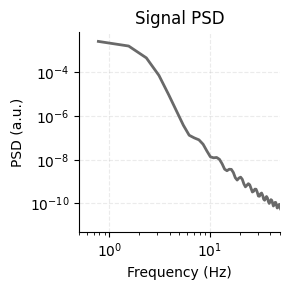

In [12]:
# ============== PLOT: PSD ==============
from scipy.signal import welch
from scipy.ndimage import gaussian_filter1d

# Assume a sampling rate (adjust as needed)
fs = 200.0  # Hz

# Scale Welch params to the signal length
nperseg  = min(256, len(signal))
noverlap = nperseg // 2

# Compute PSD using Welch method
freqs, psd = welch(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)

# Smooth PSD
psd_smooth = gaussian_filter1d(psd, sigma=1)

# Plot PSD
fig, ax = plt.subplots(figsize=(3, 3))
ax.loglog(freqs[freqs > 0], psd_smooth[freqs > 0], 'dimgray', lw=2)
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0.5, 50])
ax.set_ylabel("PSD (a.u.)")
ax.set_title("Signal PSD")
ax.grid(True, ls="--", alpha=0.25)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()